# Figures

In [1]:
import os
import sys

ROOT_DIR = os.path.normpath(os.path.join(os.getcwd(), "..", "..", ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [3]:
plt.rcParams.update({
    "text.usetex"    : False,
    "font.family"    : "serif",
    "font.size"      : 11,
    "axes.titlesize" : 12,
    "figure.dpi"     : 150,
    "savefig.dpi"    : 150,
})

In [5]:
# ── 텍스트 크기 ──────────────────────────────────────────────
FS_LABEL = 9     # 축 레이블: "Real", "Imaginary", "x", "y"
FS_TICK  = 9     # 눈금 레이블: "0", "1", "1+a", "σ", x축 숫자
FS_RECT  = 10    # 직사각형 내부 분수 레이블 (Fig 1, 2)
FS_CURVE = 10    # 곡선 레이블: "y = 1/x^s" (Fig 1, 2)
FS_ANNOT = 7     # 벡터 끝점 좌표 레이블 (Fig 3, 4)
FS_TITLE = 10    # set_title (Fig 3, 4)

# ── 마커 크기 ────────────────────────────────────────────────
MS_ARROW = 4     # 축 화살표 마커 (">k", "^k")
MS_DOT   = 5     # 수렴점 마커 (Fig 3, 4)
MS_POLE  = 6     # 열린 원 마커 — pole (Fig 5)
MS_POINT = 4     # 점 σ+it 마커 (Fig 5)

# ── 선 두께 ──────────────────────────────────────────────────
LW_CURVE = 1.5   # 곡선 y=1/x^s (Fig 1, 2)
LW_TICK  = 0.7   # 눈금 선, 경계선
LW_ARROW = 1.2   # 벡터 화살표 (Fig 3, 4)
LW_RED   = 1.5   # 빨간 실수축 선 (Fig 5)
LW_RED_V = 1.2   # 빨간 수직선 (Fig 5)

## Figure 1. 적분 판정법 — 상한 도출

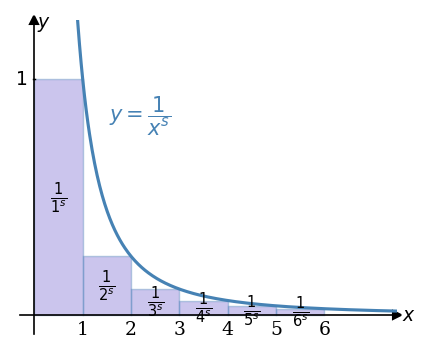

In [38]:
s     = 2.0
N     = 6
x_max = 7.5

fig, ax = plt.subplots(figsize=(3, 2.5))

# ── 곡선 y = 1/x^s ──────────────────────────────────────────
x_curve = np.linspace(0.55, x_max, 400)
ax.plot(x_curve, 1 / x_curve**s,
        color="steelblue", lw=LW_CURVE, zorder=3)

# 곡선 레이블
ax.text(1.55, 0.82, r"$y = \dfrac{1}{x^s}$",
        color="steelblue", fontsize=FS_CURVE)

# ── 직사각형 (상한 배치: 구간 [n-1, n], 높이 1/n^s) ──────────
for n in range(1, N + 1):
    height = 1.0 / n**s
    rect = patches.Rectangle(
        (n - 1, 0), 1, height,
        linewidth=LW_TICK,
        edgecolor="steelblue",
        facecolor="slateblue",
        alpha=0.35,
        zorder=2,
    )
    ax.add_patch(rect)
    label_y = height / 2
    ax.text(n - 0.5, label_y,
            r"$\frac{1}{" + str(n) + r"^s}$",
            ha="center", va="center",
            fontsize=FS_RECT, color="black")

# ── 축 설정 ─────────────────────────────────────────────────
ax.set_xlim(-0.3, x_max)
ax.set_ylim(-0.08, 1.25)
ax.set_aspect("auto")

ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.plot(x_max, 0,    ">k", ms=MS_ARROW, clip_on=False)
ax.plot(0,     1.25, "^k", ms=MS_ARROW, clip_on=False)

# 축 레이블
ax.text(x_max + 0.1, 0,    r"$x$", va="center",  fontsize=FS_LABEL)
ax.text(0.2,         1.22, r"$y$", ha="center",  fontsize=FS_LABEL)

# x축 눈금 (1~6)
for n in range(1, N + 1):
    ax.text(n, -0.02, str(n), ha="center", va="top", fontsize=FS_TICK)

# y축 눈금 (1)
ax.text(-0.15, 1.0, r"$1$", ha="right", va="center", fontsize=FS_TICK)
ax.plot([-0.02, 0.02], [1, 1], "k-", lw=LW_TICK)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-002-001.png"), bbox_inches="tight")
plt.show()

## Figure 2. 적분 판정법 — 하한 도출

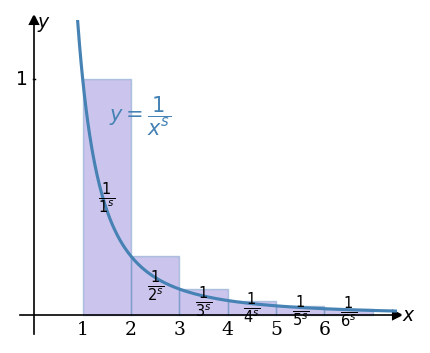

In [39]:
s     = 2.0
N     = 6
x_max = 7.5

fig, ax = plt.subplots(figsize=(3, 2.5))

# ── 곡선 y = 1/x^s ──────────────────────────────────────────
x_curve = np.linspace(0.55, x_max, 400)
ax.plot(x_curve, 1 / x_curve**s,
        color="steelblue", lw=LW_CURVE, zorder=3)

# 곡선 레이블
ax.text(1.55, 0.82, r"$y = \dfrac{1}{x^s}$",
        color="steelblue", fontsize=FS_CURVE)

# ── 직사각형 (하한 배치: 구간 [n, n+1], 높이 1/n^s) ──────────
for n in range(1, N + 1):
    height = 1.0 / n**s
    rect = patches.Rectangle(
        (n, 0), 1, height,
        linewidth=LW_TICK,
        edgecolor="steelblue",
        facecolor="slateblue",
        alpha=0.35,
        zorder=2,
    )
    ax.add_patch(rect)
    label_y = height / 2
    ax.text(n + 0.5, label_y,
            r"$\frac{1}{" + str(n) + r"^s}$",
            ha="center", va="center",
            fontsize=FS_RECT, color="black")

# ── 축 설정 ─────────────────────────────────────────────────
ax.set_xlim(-0.3, x_max)
ax.set_ylim(-0.08, 1.25)
ax.set_aspect("auto")

ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

ax.plot(x_max, 0,    ">k", ms=MS_ARROW, clip_on=False)
ax.plot(0,     1.25, "^k", ms=MS_ARROW, clip_on=False)

# 축 레이블
ax.text(x_max + 0.1, 0,    r"$x$", va="center", fontsize=FS_LABEL)
ax.text(0.2,         1.22, r"$y$", ha="center", fontsize=FS_LABEL)

# x축 눈금 (1~6)
for n in range(1, N + 1):
    ax.text(n, -0.02, str(n), ha="center", va="top", fontsize=FS_TICK)

# y축 눈금 (1)
ax.text(-0.15, 1.0, r"$1$", ha="right", va="center", fontsize=FS_TICK)
ax.plot([-0.02, 0.02], [1, 1], "k-", lw=LW_TICK)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-002-002.png"), bbox_inches="tight")
plt.show()

## Figure 3. 복소평면에서 $\zeta(2+3i)$의 벡터 합산


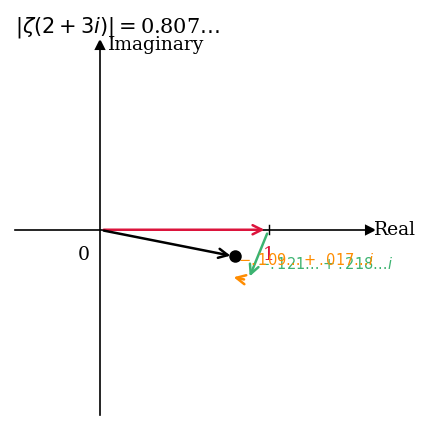

In [40]:
s      = 2 + 3j
N_show = 3
N_sum  = 200
COLORS = ["crimson", "mediumseagreen", "darkorange"]

terms    = [1.0 / (n ** s) for n in range(1, N_show + 1)]
zeta_val = sum(1.0 / (n ** s) for n in range(1, N_sum + 1))

endpoints = []
cumsum = 0 + 0j
for term in terms:
    cumsum += term
    endpoints.append(cumsum)

fig, ax = plt.subplots(figsize=(3, 3))

ax.set_xlim(-0.5, 1.6)
ax.set_ylim(-0.8, 0.8)

ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.plot(1.6,  0,   ">k", ms=MS_ARROW, clip_on=False)
ax.plot(0,    0.8, "^k", ms=MS_ARROW, clip_on=False)

# 축 레이블
ax.text(1.62, 0,    "Real",      va="center", fontsize=FS_LABEL)
ax.text(0.05, 0.78, "Imaginary", ha="left",   fontsize=FS_LABEL)

# 원점, 눈금
ax.text(-0.06, -0.07, "0", ha="right", va="top",    fontsize=FS_TICK)
ax.plot([1, 1], [-0.02, 0.02], "k-", lw=LW_TICK)
ax.text(1, -0.07, "1", ha="center", va="top",
        fontsize=FS_TICK, color="crimson")

# ── 각 항 벡터 (화살표) ─────────────────────────────────────
prev = 0 + 0j
for i, (term, endpoint) in enumerate(zip(terms, endpoints)):
    ax.annotate(
        "", xy=(endpoint.real, endpoint.imag),
        xytext=(prev.real, prev.imag),
        arrowprops=dict(arrowstyle="->", color=COLORS[i], lw=LW_ARROW),
    )
    prev = endpoint

# 끝점 레이블
ax.text(endpoints[1].real + 0.05, endpoints[1].imag + 0.04,
        r"$-.121{\ldots} + .218{\ldots}i$",
        fontsize=FS_ANNOT, color=COLORS[1], va="bottom")
ax.text(endpoints[2].real + 0.05, endpoints[2].imag + 0.04,
        r"$-.109{\ldots} + .017{\ldots}i$",
        fontsize=FS_ANNOT, color=COLORS[2], va="bottom")

# 수렴점 및 modulus 화살표
ax.plot(zeta_val.real, zeta_val.imag,
        "o", color="black", ms=MS_DOT, zorder=5)
ax.annotate(
    "", xy=(zeta_val.real, zeta_val.imag),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle="->", color="black", lw=LW_ARROW),
)

ax.set_title(r"$|\zeta(2+3i)| = $" + f"{abs(zeta_val):.3f}" + r"$\ldots$",
             loc="left", fontsize=FS_TITLE)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-002-003.png"), bbox_inches="tight")
plt.show()

## Figure 4. 복소평면에서 $\zeta(2)$의 벡터 합산

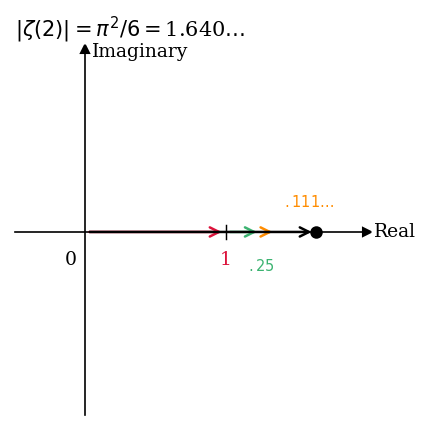

In [6]:
s      = 2 + 0j
N_show = 3
N_sum  = 200
COLORS = ["crimson", "mediumseagreen", "darkorange"]

terms    = [1.0 / (n ** s) for n in range(1, N_show + 1)]
zeta_val = sum(1.0 / (n ** s) for n in range(1, N_sum + 1))

endpoints = []
cumsum = 0 + 0j
for term in terms:
    cumsum += term
    endpoints.append(cumsum)

fig, ax = plt.subplots(figsize=(3, 3))

ax.set_xlim(-0.5, 2.0)
ax.set_ylim(-0.5, 0.5)

ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.plot(2.0, 0,   ">k", ms=MS_ARROW, clip_on=False)
ax.plot(0,   0.5, "^k", ms=MS_ARROW, clip_on=False)

# 축 레이블
ax.text(2.05, 0,    "Real",      va="center", fontsize=FS_LABEL)
ax.text(0.05, 0.48, "Imaginary", ha="left",   fontsize=FS_LABEL)

# 원점, 눈금
ax.text(-0.06, -0.05, "0", ha="right", va="top",    fontsize=FS_TICK)
ax.plot([1, 1], [-0.02, 0.02], "k-", lw=LW_TICK)
ax.text(1, -0.05, "1", ha="center", va="top",
        fontsize=FS_TICK, color="crimson")

# ── 각 항 벡터 (화살표) ─────────────────────────────────────
prev = 0 + 0j
for i, (term, endpoint) in enumerate(zip(terms, endpoints)):
    ax.annotate(
        "", xy=(endpoint.real, endpoint.imag),
        xytext=(prev.real, prev.imag),
        arrowprops=dict(arrowstyle="->", color=COLORS[i], lw=LW_ARROW),
    )
    prev = endpoint

# 끝점 레이블
ax.text(endpoints[1].real, -0.07,
        r"$.25$",
        ha="center", va="top", fontsize=FS_ANNOT, color=COLORS[1])
ax.text(endpoints[2].real + 0.05, 0.06,
        r"$.111{\ldots}$",
        ha="left", va="bottom", fontsize=FS_ANNOT, color=COLORS[2])

# 수렴점 및 modulus 화살표
ax.plot(zeta_val.real, zeta_val.imag,
        "o", color="black", ms=MS_DOT, zorder=5)
ax.annotate(
    "", xy=(zeta_val.real, zeta_val.imag),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle="->", color="black", lw=LW_ARROW),
)

ax.set_title(r"$|\zeta(2)| = \pi^2/6 = $" + f"{zeta_val.real:.3f}" + r"$\ldots$",
             loc="left", fontsize=FS_TITLE)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-002-004.png"), bbox_inches="tight")
plt.show()

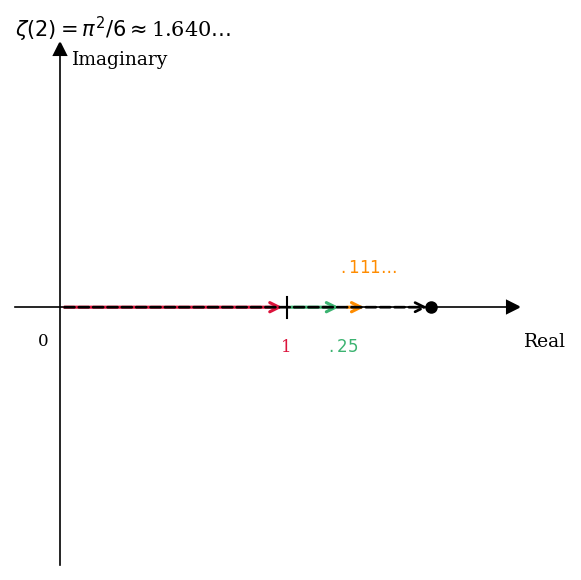

In [7]:
import os
import matplotlib.pyplot as plt

# ── 상수 정의 (상황에 맞게 크기 조절 가능) ───────────────────
MS_ARROW = 6
MS_DOT = 5
FS_LABEL = 9
FS_TICK = 8
FS_ANNOT = 8
FS_TITLE = 10
LW_TICK = 1.0
LW_ARROW = 1.5

# ── 데이터 계산 ──────────────────────────────────────────────
s = 2 + 0j
N_show = 3
N_sum = 200
COLORS = ["crimson", "mediumseagreen", "darkorange"]

# 각 항 계산 (1, 1/4, 1/9)
terms = [1.0 / (n ** s) for n in range(1, N_show + 1)]
zeta_val = sum(1.0 / (n ** s) for n in range(1, N_sum + 1))

endpoints = []
cumsum = 0 + 0j
for term in terms:
    cumsum += term
    endpoints.append(cumsum)

# ── 시각화 설정 ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 4))

ax.set_xlim(-0.2, 2.0)
ax.set_ylim(-0.5, 0.5)

# 축 설정 (원점 기준으로 교차)
ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# 축 화살표 표시
ax.plot(2.0, 0, ">k", ms=MS_ARROW, clip_on=False)
ax.plot(0, 0.5, "^k", ms=MS_ARROW, clip_on=False)

# 축 레이블 (축에 겹치지 않게 오프셋 조정)
ax.text(2.05, -0.05, "Real", va="top", ha="left", fontsize=FS_LABEL)
ax.text(0.05, 0.48, "Imaginary", ha="left", va="center", fontsize=FS_LABEL)

# 원점 표시
ax.text(-0.05, -0.05, "0", ha="right", va="top", fontsize=FS_TICK)

# ── 각 항 벡터 (화살표) 그리기 ─────────────────────────────────
# s의 허수부가 0이므로 모두 y=0(실수축) 위를 지나게 됩니다.
prev = 0 + 0j
for i, (term, endpoint) in enumerate(zip(terms, endpoints)):
    ax.annotate(
        "", xy=(endpoint.real, endpoint.imag),
        xytext=(prev.real, prev.imag),
        arrowprops=dict(arrowstyle="->", color=COLORS[i], lw=LW_ARROW),
    )
    prev = endpoint

# 첫 번째 항 (1.0) 끝점 눈금 및 레이블
ax.plot([1, 1], [-0.02, 0.02], "k-", lw=LW_TICK)
ax.text(1, -0.06, "1", ha="center", va="top", fontsize=FS_TICK, color=COLORS[0])

# 두 번째 항 (+0.25) 끝점 레이블 (위치: 1.25)
ax.text(endpoints[1].real, -0.06, r"$.25$", 
        ha="center", va="top", fontsize=FS_ANNOT, color=COLORS[1])

# 세 번째 항 (+0.111...) 끝점 레이블 (위치: 1.361...)
ax.text(endpoints[2].real, 0.06, r"$.111{\ldots}$", 
        ha="center", va="bottom", fontsize=FS_ANNOT, color=COLORS[2])

# ── 원점에서 수렴값까지의 검은색 벡터 및 점 표시 ───────────────
# 원점에서 시작하여 최종 수렴점(pi^2/6)으로 향하는 검은색 화살표
ax.annotate(
    "", xy=(zeta_val.real, zeta_val.imag),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle="->", color="black", lw=LW_ARROW - 0.2, ls="--"),
)
ax.plot(zeta_val.real, zeta_val.imag, "o", color="black", ms=MS_DOT, zorder=5)

# ── 타이틀 및 마무리 ──────────────────────────────────────────
ax.set_title(r"$\zeta(2) = \pi^2/6 \approx $" + f"{zeta_val.real:.3f}" + r"$\ldots$",
             loc="left", fontsize=FS_TITLE)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()

# 이미지 저장 경로 설정 (os.path 사용 권장 지침 준수)
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-002-004.png"), bbox_inches="tight")
plt.show()

## Figure 5. $\operatorname{Re}(s) \geq 1+a$ 영역에서 $|\zeta(s)|$의 상한

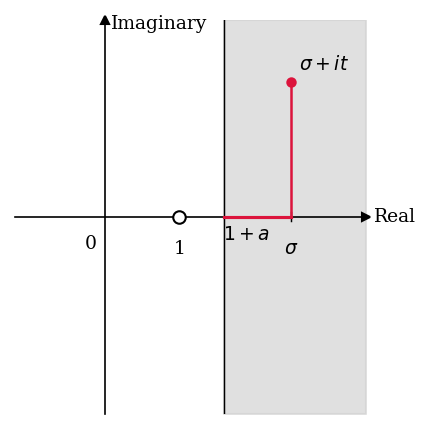

In [42]:
a     = 0.6
sigma = 2.5
t     = 1.5

x_min, x_max = -1.2, 3.5
y_min, y_max = -2.2, 2.2

fig, ax = plt.subplots(figsize=(3, 3))

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# 회색 음영 반평면
ax.fill_betweenx([y_min, y_max], 1 + a, x_max,
                 color="lightgray", alpha=0.7, zorder=1)

ax.spines["left"].set_position("zero")
ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.plot(x_max, 0,     ">k", ms=MS_ARROW, clip_on=False)
ax.plot(0,     y_max, "^k", ms=MS_ARROW, clip_on=False)

# 축 레이블
ax.text(x_max + 0.1, 0,          "Real",      va="center", fontsize=FS_LABEL)
ax.text(0.08,        y_max - 0.1, "Imaginary", ha="left",   fontsize=FS_LABEL)

# 실수축 눈금 및 레이블
ax.text(-0.1, -0.2, "0", ha="right", va="top", fontsize=FS_TICK)

# "1" — 열린 원 (pole)
ax.plot(1, 0, "o", color="white", ms=MS_POLE,
        markeredgecolor="black", markeredgewidth=1.0, zorder=4)
ax.text(1, -0.25, "1", ha="center", va="top", fontsize=FS_TICK)

# "1+a" 경계
ax.plot([1 + a, 1 + a], [y_min, y_max], "k-", lw=LW_TICK, zorder=2)
ax.text(1.3 + a, -0.1, r"$1+a$", ha="center", va="top", fontsize=FS_TICK)

# "σ" 눈금
ax.plot([sigma, sigma], [-0.05, 0.05], "k-", lw=LW_TICK)
ax.text(sigma, -0.25, r"$\sigma$", ha="center", va="top", fontsize=FS_TICK)

# 빨간 실수축 선 (1+a ~ σ)
ax.plot([1 + a, sigma], [0, 0], color="crimson", lw=LW_RED, zorder=3)

# 빨간 수직선 (σ ~ σ+it)
ax.plot([sigma, sigma], [0, t], color="crimson", lw=LW_RED_V, zorder=3)

# 점 σ+it
ax.plot(sigma, t, "o", color="crimson", ms=MS_POINT, zorder=5)
ax.text(sigma + 0.1, t + 0.1,
        r"$\sigma + it$", ha="left", va="bottom", fontsize=FS_TICK)

ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-002-005.png"), bbox_inches="tight")
plt.show()